# OEIS A112509 — Extended Results ($n = 1$ to $150$)

This notebook presents some results and analysis for A112509 which helped in designing algorithms.  These were generated using an optimized block-based search algorithm.

Results are cached in `data/cached_results.json`.

In [1]:
import sys, os

# Set project root relative to this notebook (works for any user)
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
sys.path.insert(0, PROJECT_ROOT)

import json
import math
import re
from IPython.display import display, HTML
from data.reference.known_values import KNOWN_VALUES

# Helper functions
def run_lengths(s, ch):
    """Return list of lengths of maximal runs of character ch in s."""
    return [len(m.group()) for m in re.finditer(f'{ch}+', s)]

def fmt_range(vals):
    """Format a set/list of ints as 'min-max' or just 'val' if all same."""
    lo, hi = min(vals), max(vals)
    return str(lo) if lo == hi else f"{lo}–{hi}"


## Load Cached Results

In [2]:
cache_path = os.path.join(PROJECT_ROOT, "data", "cached_results.json")
with open(cache_path, "r") as f:
    cache = json.load(f)

print(f"✓ Loaded {len(cache)} cached values")
print(f"✓ Range: n={min(int(k) for k in cache.keys())} to n={max(int(k) for k in cache.keys())}")

✓ Loaded 150 cached values
✓ Range: n=1 to n=150


## Sequence Values and Optimal Strings (All Values)

In [3]:
# Build complete results list for all n values
all_results = []
for key in sorted(cache.keys(), key=int):
    n = int(key)
    entry = cache[key]
    known = KNOWN_VALUES[n - 1] if n <= len(KNOWN_VALUES) else None
    match = entry["a(n)"] == known if known is not None else None
    all_results.append({
        "n": n,
        "a(n)": entry["a(n)"],
        "known": known,
        "match": match,
        "num_optimal": entry["num_optimal"],
        "optimal_strings": entry["optimal_strings"],
        "K_common": entry.get("K_common"),
        "common_seps": entry.get("common_seps"),
    })

# Function to generate table rows for a range of n
def generate_result_rows(results, start_n, end_n):
    rows = ""
    for r in results:
        n = r["n"]
        if n < start_n or n > end_n:
            continue
        check = "✓" if r["match"] else ("✗" if r["match"] is False else "–")
        strs_html = ", &nbsp;".join(f"<code>{s}</code>" for s in r["optimal_strings"])
        h_val = math.log2(r["num_optimal"]) if r["num_optimal"] > 1 else 0.0
        rows += (
            f"<tr>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:right'>{r['a(n)']}</td>"
            f"<td style='text-align:center'>{check}</td>"
            f"<td style='text-align:right'>{r['num_optimal']}</td>"
            f"<td style='text-align:right'>{h_val:.3f}</td>"
            f"<td style='text-align:left; max-width:800px; word-wrap:break-word'>{strs_html}</td>"
            f"</tr>\n"
        )
    return rows

# Generate tables for each group of 10
max_n = max(r["n"] for r in all_results)
groups = []
for start in range(1, max_n + 1, 10):
    end = min(start + 9, max_n)
    groups.append((start, end))

# Build HTML with tabs/buttons
buttons_html = ""
tables_html = ""

for i, (start, end) in enumerate(groups):
    group_id = f"results_group_{start}_{end}"
    active = "active-res" if i == 0 else ""
    display_style = "block" if i == 0 else "none"
    
    buttons_html += f'<button class="res-btn {active}" onclick="showResultsGroup(\'{group_id}\')">n={start}–{end}</button>\n'
    
    rows = generate_result_rows(all_results, start, end)
    tables_html += f"""
<div id="{group_id}" class="results-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:right;">n</th>
  <th style="padding:4px 10px; text-align:right;">a(n)</th>
  <th style="padding:4px 10px; text-align:center;">✓</th>
  <th style="padding:4px 10px; text-align:right;"># optimal</th>
  <th style="padding:4px 10px; text-align:right;" title="log₂(# optimal strings)">H(n)</th>
  <th style="padding:4px 10px; text-align:left;">all optimal strings</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html = f"""
<style>
.res-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.res-btn:hover {{
    background-color: #ddd;
}}
.res-btn.active-res {{
    background-color: #2196F3;
    color: white;
    border-bottom: 2px solid #2196F3;
}}
.results-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>

<script>
function showResultsGroup(groupId) {{
    var tables = document.getElementsByClassName('results-table');
    for (var i = 0; i < tables.length; i++) {{
        tables[i].style.display = 'none';
    }}
    var buttons = document.getElementsByClassName('res-btn');
    for (var i = 0; i < buttons.length; i++) {{
        buttons[i].classList.remove('active-res');
    }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-res');
}}
</script>

<h3>Sequence Values and Optimal Strings</h3>
<p style="font-size:12px; color:#555;">H(n) = log₂(# optimal strings): entropy of the optimal solution set.
H(n) = 0 means a unique optimal string; larger values indicate multiple optima.</p>
<div style="margin-bottom: 10px;">
{buttons_html}
</div>
{tables_html}
"""

display(HTML(html))


n,a(n),✓,# optimal,H(n),all optimal strings
1,1,✓,2,1.000,"0, 1"
2,3,✓,1,0.000,10
3,5,✓,1,0.000,110
4,7,✓,3,1.585,"1100, 1101, 1110"
5,10,✓,2,1.000,"11100, 11101"
6,13,✓,6,2.585,"111000, 111001, 111010, 111011, 111100, 111101"
7,17,✓,5,2.322,"1110100, 1111000, 1111001, 1111010, 1111011"
8,22,✓,1,0.000,11110100
9,27,✓,4,2.000,"111101000, 111101001, 111101100, 111110100"
10,33,✓,5,2.322,"1111011000, 1111011001, 1111101000, 1111101001, 1111101100"


## Structural Analysis (By Groups of 10)

In [4]:

# ── TABLE 1: n = 1 to 100 ──────────────────────────────────────────────

def generate_structural_rows(results, start_n, end_n):
    rows = ""
    for r in results:
        n = r["n"]
        if n < start_n or n > end_n:
            continue

        strs = r["optimal_strings"]
        k_common_str = str(r["K_common"]) if r.get("K_common") is not None else "–"
        common_seps = r.get("common_seps")
        seps_str = str(common_seps) if common_seps is not None else "–"

        leading_1s = [len(s) - len(s.lstrip("1")) for s in strs]

        second_1blocks = []
        for s in strs:
            blocks_1 = run_lengths(s, '1')
            if len(blocks_1) >= 2:
                second_1blocks.append(blocks_1[1])
        second_1block_str = fmt_range(second_1blocks) if second_1blocks else "–"

        num_1blocks = [len(run_lengths(s, '1')) for s in strs]
        num_0blocks = [len(run_lengths(s, '0')) for s in strs]
        num_1blocks_str = fmt_range(num_1blocks) if num_1blocks else "–"
        num_0blocks_str = fmt_range(num_0blocks) if num_0blocks else "–"

        total_1s = [s.count('1') for s in strs]
        total_0s = [s.count('0') for s in strs]
        total_1s_str = fmt_range(total_1s)
        total_0s_str = fmt_range(total_0s)

        strs_with_0 = [s for s in strs if '0' in s]
        if strs_with_0:
            longest_0 = fmt_range([max(run_lengths(s, '0')) for s in strs_with_0])
        else:
            longest_0 = "–"

        densities = [s.count("1") / n for s in strs]
        min_density = min(densities)
        max_density = max(densities)
        density_str = f"{min_density:.2f}" if min_density == max_density else f"{min_density:.2f}–{max_density:.2f}"

        rows += (
            f"<tr>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:center'>{num_1blocks_str}</td>"
            f"<td style='text-align:center'>{num_0blocks_str}</td>"
            f"<td style='text-align:center'>{total_1s_str}</td>"
            f"<td style='text-align:center'>{total_0s_str}</td>"
            f"<td style='text-align:center'>{fmt_range(leading_1s)}</td>"
            f"<td style='text-align:center'>{second_1block_str}</td>"
            f"<td style='text-align:center'>{longest_0}</td>"
            f"<td style='text-align:right'>{density_str}</td>"
            f"<td style='text-align:center'>{k_common_str}</td>"
            f"<td style='text-align:left; font-size:11px; color:#555;'>{seps_str}</td>"
            f"<td style='text-align:right'>{r['num_optimal']}</td>"
            f"</tr>\n"
        )
    return rows

results_1_100 = [r for r in all_results if 1 <= r["n"] <= 100]
results_101_plus = [r for r in all_results if r["n"] > 100]

# Build tabs for n=1..100
groups_1_100 = []
for start in range(1, 101, 10):
    end = min(start + 9, 100)
    if any(r["n"] >= start and r["n"] <= end for r in results_1_100):
        groups_1_100.append((start, end))

buttons_html_1 = ""
tables_html_1 = ""

for i, (start, end) in enumerate(groups_1_100):
    group_id = f"struct1_group_{start}_{end}"
    active = "active-struct1" if i == 0 else ""
    display_style = "block" if i == 0 else "none"

    buttons_html_1 += f'<button class="struct1-btn {active}" onclick="showStruct1Group(\'{group_id}\')">n={start}–{end}</button>\n'

    rows = generate_structural_rows(results_1_100, start, end)
    tables_html_1 += f"""
<div id="{group_id}" class="struct1-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 8px; text-align:right;">n</th>
  <th style="padding:4px 8px; text-align:center;"># 1-blocks</th>
  <th style="padding:4px 8px; text-align:center;"># 0-blocks</th>
  <th style="padding:4px 8px; text-align:center;">total 1s</th>
  <th style="padding:4px 8px; text-align:center;">total 0s</th>
  <th style="padding:4px 8px; text-align:center;">leading 1s</th>
  <th style="padding:4px 8px; text-align:center;">2nd 1-block</th>
  <th style="padding:4px 8px; text-align:center;">max 0-run</th>
  <th style="padding:4px 8px; text-align:right;">1-density</th>
  <th style="padding:4px 8px; text-align:center;">K_common</th>
  <th style="padding:4px 8px; text-align:left;">common seps</th>
  <th style="padding:4px 8px; text-align:right;"># opt</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html1 = f"""
<style>
.struct1-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.struct1-btn:hover {{ background-color: #ddd; }}
.struct1-btn.active-struct1 {{
    background-color: #4CAF50;
    color: white;
    border-bottom: 2px solid #4CAF50;
}}
.struct1-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showStruct1Group(groupId) {{
    var tables = document.getElementsByClassName('struct1-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('struct1-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-struct1'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-struct1');
}}
</script>
<h3>Structural Analysis: n = 1–100</h3>
<div style="margin-bottom: 10px;">{buttons_html_1}</div>
{tables_html_1}
"""
display(HTML(html1))

# ── TABLE 2: n = 101+ ──────────────────────────────────────────────────

def generate_structural_rows_extended(results, start_n, end_n):
    rows = ""
    for r in results:
        n = r["n"]
        if n < start_n or n > end_n:
            continue

        strs = r["optimal_strings"]
        k_common_str = str(r["K_common"]) if r.get("K_common") is not None else "–"
        common_seps = r.get("common_seps")
        seps_str = str(common_seps) if common_seps is not None else "–"

        leading_1s = [len(s) - len(s.lstrip("1")) for s in strs]

        def nth_1block(strs, idx):
            vals = []
            for s in strs:
                blocks_1 = run_lengths(s, '1')
                if len(blocks_1) > idx:
                    vals.append(blocks_1[idx])
            return fmt_range(vals) if vals else "–"

        second_1block_str = nth_1block(strs, 1)
        third_1block_str  = nth_1block(strs, 2)
        fifth_1block_str  = nth_1block(strs, 4)

        num_1blocks = [len(run_lengths(s, '1')) for s in strs]
        num_0blocks = [len(run_lengths(s, '0')) for s in strs]
        num_1blocks_str = fmt_range(num_1blocks) if num_1blocks else "–"
        num_0blocks_str = fmt_range(num_0blocks) if num_0blocks else "–"

        total_1s = [s.count('1') for s in strs]
        total_0s = [s.count('0') for s in strs]
        total_1s_str = fmt_range(total_1s)
        total_0s_str = fmt_range(total_0s)

        strs_with_0 = [s for s in strs if '0' in s]
        longest_0 = fmt_range([max(run_lengths(s, '0')) for s in strs_with_0]) if strs_with_0 else "–"

        densities = [s.count("1") / n for s in strs]
        min_d, max_d = min(densities), max(densities)
        density_str = f"{min_d:.4f}" if min_d == max_d else f"{min_d:.4f}–{max_d:.4f}"

        rows += (
            f"<tr>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:center'>{num_1blocks_str}</td>"
            f"<td style='text-align:center'>{num_0blocks_str}</td>"
            f"<td style='text-align:center'>{total_1s_str}</td>"
            f"<td style='text-align:center'>{total_0s_str}</td>"
            f"<td style='text-align:center'>{fmt_range(leading_1s)}</td>"
            f"<td style='text-align:center'>{second_1block_str}</td>"
            f"<td style='text-align:center'>{third_1block_str}</td>"
            f"<td style='text-align:center'>{fifth_1block_str}</td>"
            f"<td style='text-align:center'>{longest_0}</td>"
            f"<td style='text-align:right'>{density_str}</td>"
            f"<td style='text-align:center'>{k_common_str}</td>"
            f"<td style='text-align:left; font-size:11px; color:#555;'>{seps_str}</td>"
            f"<td style='text-align:right'>{r['num_optimal']}</td>"
            f"</tr>\n"
        )
    return rows

if results_101_plus:
    max_n_ext = max(r["n"] for r in results_101_plus)
    groups_101 = []
    for start in range(101, max_n_ext + 1, 10):
        end = min(start + 9, max_n_ext)
        if any(r["n"] >= start and r["n"] <= end for r in results_101_plus):
            groups_101.append((start, end))

    buttons_html_2 = ""
    tables_html_2 = ""

    for i, (start, end) in enumerate(groups_101):
        group_id = f"struct2_group_{start}_{end}"
        active = "active-struct2" if i == 0 else ""
        display_style = "block" if i == 0 else "none"

        buttons_html_2 += f'<button class="struct2-btn {active}" onclick="showStruct2Group(\'{group_id}\')">n={start}–{end}</button>\n'

        rows = generate_structural_rows_extended(results_101_plus, start, end)
        tables_html_2 += f"""
<div id="{group_id}" class="struct2-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 8px; text-align:right;">n</th>
  <th style="padding:4px 8px; text-align:center;"># 1-blk</th>
  <th style="padding:4px 8px; text-align:center;"># 0-blk</th>
  <th style="padding:4px 8px; text-align:center;">total 1s</th>
  <th style="padding:4px 8px; text-align:center;">total 0s</th>
  <th style="padding:4px 8px; text-align:center;">1st 1-blk</th>
  <th style="padding:4px 8px; text-align:center;">2nd 1-blk</th>
  <th style="padding:4px 8px; text-align:center;">3rd 1-blk</th>
  <th style="padding:4px 8px; text-align:center;">5th 1-blk</th>
  <th style="padding:4px 8px; text-align:center;">max 0-run</th>
  <th style="padding:4px 8px; text-align:right;">1-density</th>
  <th style="padding:4px 8px; text-align:center;">K_common</th>
  <th style="padding:4px 8px; text-align:left;">common seps</th>
  <th style="padding:4px 8px; text-align:right;"># opt</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

    html2 = f"""
<style>
.struct2-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.struct2-btn:hover {{ background-color: #ddd; }}
.struct2-btn.active-struct2 {{
    background-color: #9C27B0;
    color: white;
    border-bottom: 2px solid #9C27B0;
}}
.struct2-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showStruct2Group(groupId) {{
    var tables = document.getElementsByClassName('struct2-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('struct2-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-struct2'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-struct2');
}}
</script>
<h3>Structural Analysis: n ≥ 101 (Extended)</h3>
<div style="margin-bottom: 10px;">{buttons_html_2}</div>
{tables_html_2}
"""
    display(HTML(html2))
else:
    print("No results for n > 100 yet.")


n,# 1-blocks,# 0-blocks,total 1s,total 0s,leading 1s,2nd 1-block,max 0-run,1-density,K_common,common seps,# opt
1,0–1,0–1,0–1,0–1,0–1,–,1,0.00–1.00,1,[1],2
2,1,1,1,1,1,–,1,0.50,1,[1],1
3,1,1,2,1,2,–,1,0.67,1,[1],1
4,1–2,1,2–3,1–2,2–3,1,1–2,0.50–0.75,0,[],3
5,1–2,1,3–4,1–2,3,1,1–2,0.60–0.80,0,[],2
6,1–2,1–2,3–5,1–3,3–4,1–2,1–3,0.50–0.83,0,[],6
7,1–2,1–2,4–6,1–3,3–4,1–2,1–3,0.57–0.86,0,[],5
8,2,2,5,3,4,1,2,0.62,2,"[1, 2]",1
9,2–3,2,5–6,3–4,4–5,1–2,2–3,0.56–0.67,1,[1],4
10,2–3,2,6–7,3–4,4–5,1–2,2–3,0.60–0.70,1,[1],5


n,# 1-blk,# 0-blk,total 1s,total 0s,1st 1-blk,2nd 1-blk,3rd 1-blk,5th 1-blk,max 0-run,1-density,K_common,common seps,# opt
101,11–14,11–13,82–86,15–19,19–20,16–17,13–14,9–10,3–7,0.8119–0.8515,8,"[1, 2, 1, 1, 1, 1, 1, 1]",236
102,11–14,11–13,83–86,16–19,19–20,16–17,13–14,9–10,3–6,0.8137–0.8431,8,"[1, 2, 1, 1, 1, 1, 1, 1]",144
103,12–14,12–13,84–86,17–19,19–20,16–17,13–14,9–10,3–5,0.8155–0.8350,8,"[1, 2, 1, 1, 1, 1, 1, 1]",101
104,12–14,12–13,85–87,17–19,19–20,16–17,13–14,9–10,3–5,0.8173–0.8365,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",44
105,12–14,12–13,86–88,17–19,20,17,14,10,3–5,0.8190–0.8381,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",8
106,12–14,12–14,86–89,17–20,20–21,17–18,14–15,10–11,3–6,0.8113–0.8396,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",60
107,12–14,12–14,87–90,17–20,20–21,17–18,14–15,10–11,3–6,0.8131–0.8411,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",190
108,12–14,12–14,88–91,17–20,20–21,17–18,14–15,10–11,3–6,0.8148–0.8426,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",331
109,12–14,12–14,89–92,17–20,20–21,17–18,14–15,10–11,3–6,0.8165–0.8440,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",345
110,12–14,12–14,90–93,17–20,20–21,17–18,14–15,10–11,3–6,0.8182–0.8455,11,"[1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1]",218


## K_common vs n

For each $n$, **K_common** is the length of the longest 0-separator prefix that is identical across 100% of optimal solutions — a measure of how much structural rigidity is shared at the start of optimal strings.


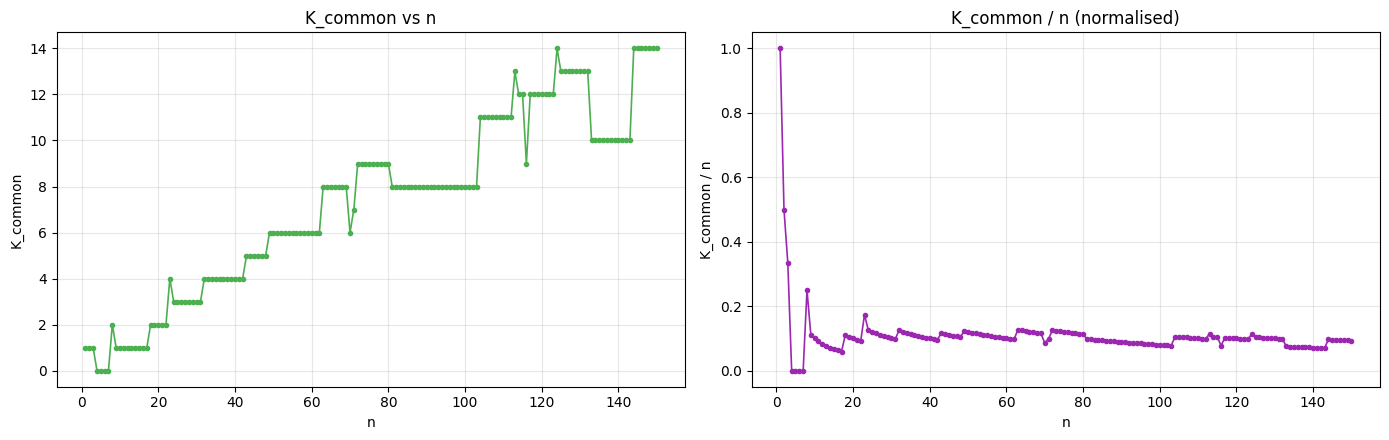

n range       : 1–150
K_common range: 0–14
Mean K_common : 7.33


In [5]:
import matplotlib.pyplot as plt

n_kc = [r["n"] for r in all_results if r.get("K_common") is not None]
k_vals = [r["K_common"] for r in all_results if r.get("K_common") is not None]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Chart 1: K_common vs n (all n)
axes[0].plot(n_kc, k_vals, marker="o", linewidth=1.2, markersize=3, color="#4CAF50")
axes[0].set_title("K_common vs n")
axes[0].set_xlabel("n")
axes[0].set_ylabel("K_common")
axes[0].grid(alpha=0.3)

# Chart 2: K_common / n (normalised fraction of separators that are shared)
kc_ratio = [k / n for k, n in zip(k_vals, n_kc)]
axes[1].plot(n_kc, kc_ratio, marker="o", linewidth=1.2, markersize=3, color="#9C27B0")
axes[1].set_title("K_common / n (normalised)")
axes[1].set_xlabel("n")
axes[1].set_ylabel("K_common / n")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"n range       : {n_kc[0]}–{n_kc[-1]}")
print(f"K_common range: {min(k_vals)}–{max(k_vals)}")
print(f"Mean K_common : {sum(k_vals)/len(k_vals):.2f}")


## Hamming Distance Between Optimal Solutions

For each $n$, this table shows the **minimum**, **maximum**, and **mean** pairwise Hamming distance between all known optimal bit-strings. When there is only one optimal solution the distances are 0 by convention.


In [6]:
from itertools import combinations
from IPython.display import display, HTML

# Compute Hamming distances from all_results (defined in earlier cell)
def hamming_dist(s1, s2):
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

hamming = {}
for r in all_results:
    n = r["n"]
    strs = r["optimal_strings"]
    num = len(strs)
    if num <= 1:
        hamming[str(n)] = {"num_solutions": num, "min": 0, "max": 0, "mean": 0.0}
    else:
        dists = [hamming_dist(a, b) for a, b in combinations(strs, 2)]
        hamming[str(n)] = {
            "num_solutions": num,
            "min": min(dists),
            "max": max(dists),
            "mean": sum(dists) / len(dists),
        }

# Build tabbed groups of 10
max_n_h = max(int(k) for k in hamming)
groups_h = []
for start in range(1, max_n_h + 1, 10):
    end = min(start + 9, max_n_h)
    if any(start <= int(k) <= end for k in hamming):
        groups_h.append((start, end))

buttons_html_h = ""
tables_html_h = ""

for i, (start, end) in enumerate(groups_h):
    group_id = f"hamming_group_{start}_{end}"
    active = "active-ham" if i == 0 else ""
    display_style = "block" if i == 0 else "none"

    buttons_html_h += f'<button class="ham-btn {active}" onclick="showHammingGroup(\'{group_id}\')">n={start}–{end}</button>\n'

    rows = ""
    for n in range(start, end + 1):
        k = str(n)
        if k not in hamming:
            continue
        h = hamming[k]
        rows += (
            f"<tr>"
            f"<td style='text-align:right; padding:3px 10px;'>{n}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{h['num_solutions']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{h['min']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{h['max']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{h['mean']:.2f}</td>"
            f"</tr>\n"
        )

    tables_html_h += f"""
<div id="{group_id}" class="hamming-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:right;">n</th>
  <th style="padding:4px 10px; text-align:right;"># Solutions</th>
  <th style="padding:4px 10px; text-align:right;">Min</th>
  <th style="padding:4px 10px; text-align:right;">Max</th>
  <th style="padding:4px 10px; text-align:right;">Mean</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html_h = f"""
<style>
.ham-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.ham-btn:hover {{ background-color: #ddd; }}
.ham-btn.active-ham {{
    background-color: #FF9800;
    color: white;
    border-bottom: 2px solid #FF9800;
}}
.hamming-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showHammingGroup(groupId) {{
    var tables = document.getElementsByClassName('hamming-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('ham-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-ham'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-ham');
}}
</script>
<h3>Hamming Distance Between Optimal Solutions</h3>
<p style="font-size:12px; color:#555;">
  Pairwise Hamming distance over all C(k,2) pairs of optimal bit-strings.
  Single-solution cases: min = max = mean = 0 by convention.
</p>
<div style="margin-bottom: 10px;">{buttons_html_h}</div>
{tables_html_h}
"""
display(HTML(html_h))

n,# Solutions,Min,Max,Mean
1,2,1,1,1.00
2,1,0,0,0.00
3,1,0,0,0.00
4,3,1,2,1.33
5,2,1,1,1.00
6,6,1,3,1.67
7,5,1,4,2.00
8,1,0,0,0.00
9,4,1,4,2.17
10,5,1,4,2.20


## Growth Analysis

In [7]:
def generate_growth_rows(results, start_n, end_n):
    rows = ""
    for i, r in enumerate(results):
        n = r["n"]
        if n < start_n or n > end_n:
            continue
        an = r["a(n)"]
        num_opt = r["num_optimal"]

        if n <= len(KNOWN_VALUES):
            value_match = "✓" if an == KNOWN_VALUES[n-1] else "✗"
        else:
            value_match = "–"

        try:
            from data.reference.known_values import A156025_VALUES
            if n <= len(A156025_VALUES):
                count_match = "✓" if num_opt == A156025_VALUES[n-1] else "✗"
            else:
                count_match = "–"
        except ImportError:
            count_match = "–"

        delta = an - results[i-1]["a(n)"] if i > 0 else None
        ddelta = None
        if i >= 2:
            d1 = results[i]["a(n)"] - results[i-1]["a(n)"]
            d0 = results[i-1]["a(n)"] - results[i-2]["a(n)"]
            ddelta = d1 - d0

        delta_str = str(delta) if delta is not None else "–"
        ddelta_str = str(ddelta) if ddelta is not None else "–"

        rows += (
            f"<tr>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:right'>{an}</td>"
            f"<td style='text-align:center'>{value_match}</td>"
            f"<td style='text-align:right'>{num_opt}</td>"
            f"<td style='text-align:center'>{count_match}</td>"
            f"<td style='text-align:right'>{delta_str}</td>"
            f"<td style='text-align:right'>{ddelta_str}</td>"
            f"<td style='text-align:right'>{an/n:.2f}</td>"
            f"<td style='text-align:right'>{an/n**2:.4f}</td>"
            f"</tr>\n"
        )
    return rows

max_n_g = max(r["n"] for r in all_results)
groups_g = []
for start in range(1, max_n_g + 1, 10):
    end = min(start + 9, max_n_g)
    if any(r["n"] >= start and r["n"] <= end for r in all_results):
        groups_g.append((start, end))

buttons_html_g = ""
tables_html_g = ""

for i, (start, end) in enumerate(groups_g):
    group_id = f"growth_group_{start}_{end}"
    active = "active-grow" if i == 0 else ""
    display_style = "block" if i == 0 else "none"

    buttons_html_g += f'<button class="grow-btn {active}" onclick="showGrowthGroup(\'{group_id}\')">n={start}–{end}</button>\n'

    rows = generate_growth_rows(all_results, start, end)
    tables_html_g += f"""
<div id="{group_id}" class="growth-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:right;">n</th>
  <th style="padding:4px 10px; text-align:right;">a(n)</th>
  <th style="padding:4px 10px; text-align:center;">a(n) ✓</th>
  <th style="padding:4px 10px; text-align:right;"># opt</th>
  <th style="padding:4px 10px; text-align:center;"># opt ✓</th>
  <th style="padding:4px 10px; text-align:right;">Δa</th>
  <th style="padding:4px 10px; text-align:right;">ΔΔa</th>
  <th style="padding:4px 10px; text-align:right;">a(n)/n</th>
  <th style="padding:4px 10px; text-align:right;">a(n)/n²</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html = f"""
<style>
.grow-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.grow-btn:hover {{ background-color: #ddd; }}
.grow-btn.active-grow {{
    background-color: #E91E63;
    color: white;
    border-bottom: 2px solid #E91E63;
}}
.growth-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showGrowthGroup(groupId) {{
    var tables = document.getElementsByClassName('growth-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('grow-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-grow'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-grow');
}}
</script>
<h3>Growth Analysis (All Values)</h3>
<div style="margin-bottom: 10px;">{buttons_html_g}</div>
{tables_html_g}
"""

display(HTML(html))

n,a(n),a(n) ✓,# opt,# opt ✓,Δa,ΔΔa,a(n)/n,a(n)/n²
1,1,✓,2,✓,–,–,1.00,1.0000
2,3,✓,1,✓,2,–,1.50,0.7500
3,5,✓,1,✓,2,0,1.67,0.5556
4,7,✓,3,✓,2,0,1.75,0.4375
5,10,✓,2,✓,3,1,2.00,0.4000
6,13,✓,6,✓,3,0,2.17,0.3611
7,17,✓,5,✓,4,1,2.43,0.3469
8,22,✓,1,✓,5,1,2.75,0.3438
9,27,✓,4,✓,5,0,3.00,0.3333
10,33,✓,5,✓,6,1,3.30,0.3300


## Plots: Normalized Growth and Number of Optimal Solutions

The first chart shows $a(n)/n^2$ across all available $n$.

For the number of optimal solutions, a log-scale y-axis is used to handle the wide range (from 1 to over 200) while keeping smaller values visible.

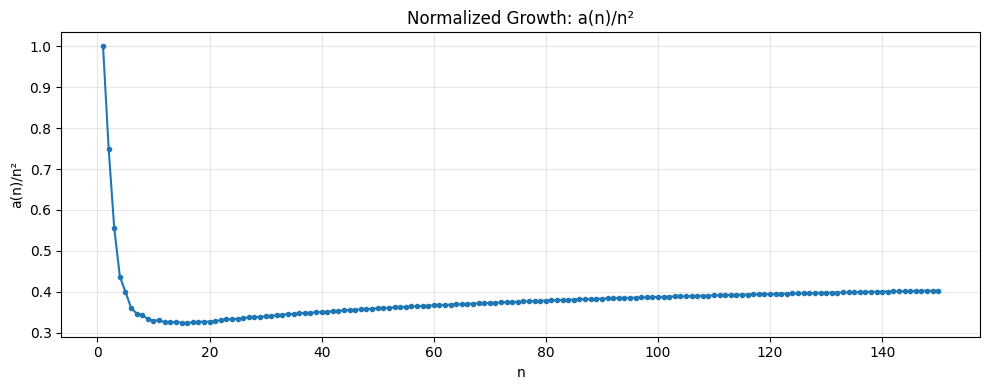

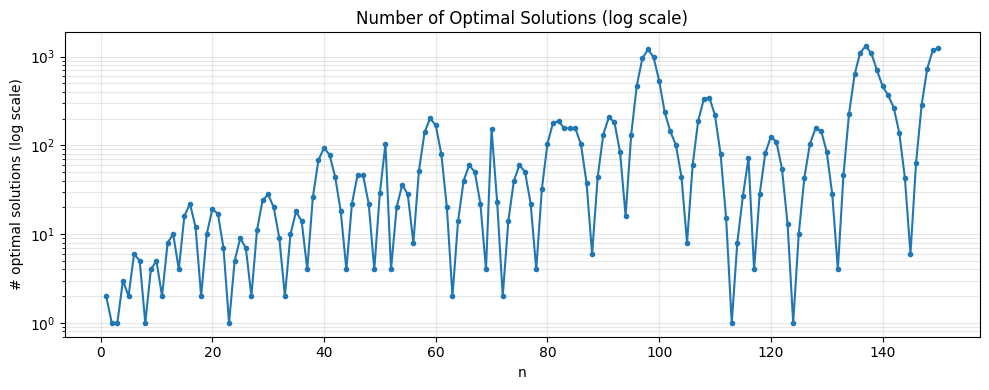

In [8]:
import matplotlib.pyplot as plt

n_vals = [r["n"] for r in all_results]
a_vals = [r["a(n)"] for r in all_results]
num_opt_vals = [r["num_optimal"] for r in all_results]

ratio_vals = [a / (n**2) for a, n in zip(a_vals, n_vals)]

# Chart 1: a(n)/n^2
plt.figure(figsize=(10, 4))
plt.plot(n_vals, ratio_vals, marker="o", linewidth=1.5, markersize=3)
plt.title("Normalized Growth: a(n)/n²")
plt.xlabel("n")
plt.ylabel("a(n)/n²")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Chart 2: Number of optimal solutions (log scale)
plt.figure(figsize=(10, 4))
plt.plot(n_vals, num_opt_vals, marker="o", linewidth=1.5, markersize=3)
plt.yscale("log")
plt.title("Number of Optimal Solutions (log scale)")
plt.xlabel("n")
plt.ylabel("# optimal solutions (log scale)")
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## De Bruijn Embedding Analysis

For each $n$, we find the minimum de Bruijn order $k$ such that an optimal $n$-bit string can be embedded as a contiguous substring of a linear de Bruijn sequence $B(2,k)$ of length $2^k + k - 1$.

- **best $k$**: the smallest $k$ achievable by any optimal string for that $n$
- **worst $k$**: the largest $k$ needed across all optimal strings for that $n$
- **$\Delta\Delta a$**: second difference of $a(n)$, included because the jumps in $k$ align with the non-constant second differences

The chart below shows best $k$ and worst $k$ vs $n$, revealing the staircase growth pattern.

In [9]:
import json, os
from IPython.display import display, HTML

db_path = os.path.join(PROJECT_ROOT, "results", "debruijn_analysis.json")

with open(db_path) as f:
    db_data = json.load(f)

# Compute ΔΔa from all_results (defined in earlier cell)
dda_by_n = {}
for i, r in enumerate(all_results):
    if i >= 2:
        d1 = all_results[i]["a(n)"] - all_results[i-1]["a(n)"]
        d0 = all_results[i-1]["a(n)"] - all_results[i-2]["a(n)"]
        dda_by_n[r["n"]] = d1 - d0

# Build tabbed groups of 10
max_n_db = max(r["n"] for r in db_data)
groups_db = []
for start in range(1, max_n_db + 1, 10):
    end = min(start + 9, max_n_db)
    if any(start <= r["n"] <= end for r in db_data):
        groups_db.append((start, end))

db_by_n = {r["n"]: r for r in db_data}

buttons_html_db = ""
tables_html_db = ""

for i, (start, end) in enumerate(groups_db):
    group_id = f"db_group_{start}_{end}"
    active = "active-db" if i == 0 else ""
    display_style = "block" if i == 0 else "none"

    buttons_html_db += f'<button class="db-btn {active}" onclick="showDbGroup(\'{group_id}\')">n={start}–{end}</button>\n'

    rows = ""
    for n in range(start, end + 1):
        if n not in db_by_n:
            continue
        r = db_by_n[n]
        k_range = r["worst_k"] - r["best_k"]
        dda = dda_by_n.get(n, None)
        dda_str = str(dda) if dda is not None else "–"
        rows += (
            f"<tr>"
            f"<td style='text-align:right; padding:3px 10px;'>{n}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['a_n']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['num_optimal']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['best_k']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['worst_k']}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{k_range}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{r['best_debruijn_length']:,}</td>"
            f"<td style='text-align:right; padding:3px 10px;'>{dda_str}</td>"
            f"</tr>\n"
        )

    tables_html_db += f"""
<div id="{group_id}" class="db-table" style="display:{display_style};">
<table style="border-collapse:collapse; font-size:13px; width:100%;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:right;">n</th>
  <th style="padding:4px 10px; text-align:right;">a(n)</th>
  <th style="padding:4px 10px; text-align:right;"># opt</th>
  <th style="padding:4px 10px; text-align:right;">best k</th>
  <th style="padding:4px 10px; text-align:right;">worst k</th>
  <th style="padding:4px 10px; text-align:right;">k range</th>
  <th style="padding:4px 10px; text-align:right;">best dB length</th>
  <th style="padding:4px 10px; text-align:right;">ΔΔa</th>
</tr>
</thead>
<tbody>
{rows}
</tbody>
</table>
</div>
"""

html_db = f"""
<style>
.db-btn {{
    background-color: #f1f1f1;
    border: 1px solid #ccc;
    padding: 8px 16px;
    cursor: pointer;
    margin-right: 2px;
    border-radius: 4px 4px 0 0;
    font-size: 14px;
}}
.db-btn:hover {{ background-color: #ddd; }}
.db-btn.active-db {{
    background-color: #00897B;
    color: white;
    border-bottom: 2px solid #00897B;
}}
.db-table {{
    margin-top: 10px;
    padding: 10px;
    border: 1px solid #ddd;
}}
</style>
<script>
function showDbGroup(groupId) {{
    var tables = document.getElementsByClassName('db-table');
    for (var i = 0; i < tables.length; i++) {{ tables[i].style.display = 'none'; }}
    var buttons = document.getElementsByClassName('db-btn');
    for (var i = 0; i < buttons.length; i++) {{ buttons[i].classList.remove('active-db'); }}
    document.getElementById(groupId).style.display = 'block';
    event.target.classList.add('active-db');
}}
</script>
<h3>De Bruijn Embedding: Minimum Order k by n</h3>
<p style="font-size:12px; color:#555;">
  For each n, best k = min over all optimal strings, worst k = max.
  A string embeds in B(2,k) iff all its k-substrings are distinct.
  ΔΔa is the second difference of a(n); k increments align with ΔΔa spikes.
</p>
<div style="margin-bottom: 10px;">{buttons_html_db}</div>
{tables_html_db}
"""
display(HTML(html_db))

n,a(n),# opt,best k,worst k,k range,best dB length,ΔΔa
1,1,2,1,1,0,2,–
2,3,1,1,1,0,2,–
3,5,1,2,2,0,5,0
4,7,3,2,3,1,5,0
5,10,2,3,3,0,10,1
6,13,6,3,4,1,10,0
7,17,5,3,4,1,10,1
8,22,1,4,4,0,19,1
9,27,4,4,5,1,19,0
10,33,5,4,5,1,19,1


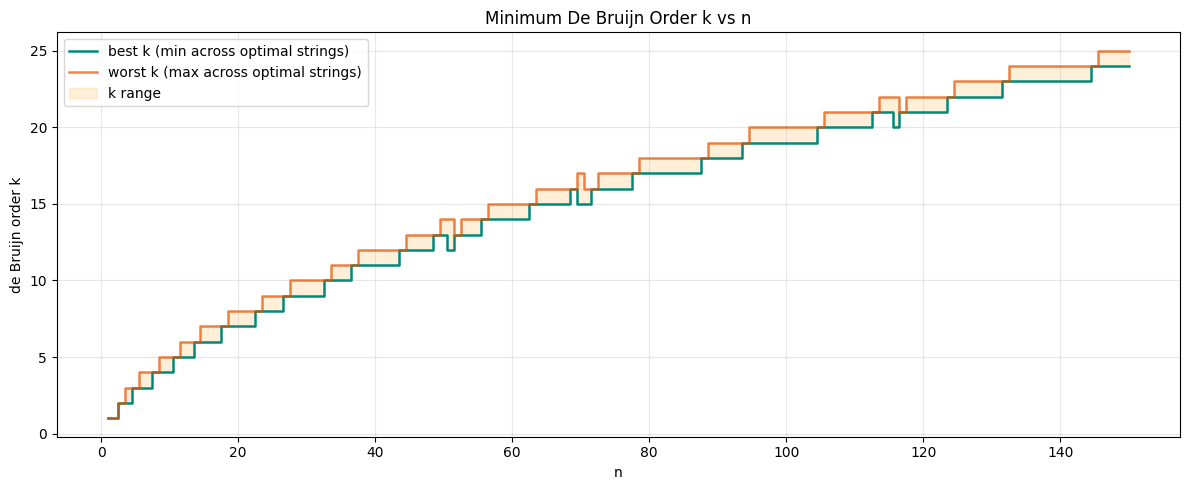

Values of n analysed: 150
  k range = 0 (all optimal strings agree): 28
  k range = 1: 119
  k range ≥ 2: 3  (n = [51, 70, 116])


In [10]:
import matplotlib.pyplot as plt

n_db = [r["n"] for r in db_data]
best_k = [r["best_k"] for r in db_data]
worst_k = [r["worst_k"] for r in db_data]

fig, ax = plt.subplots(figsize=(12, 5))

ax.step(n_db, best_k, where="mid", linewidth=1.8, color="#00897B", label="best k (min across optimal strings)")
ax.step(n_db, worst_k, where="mid", linewidth=1.8, color="#E65100", alpha=0.7, label="worst k (max across optimal strings)")
ax.fill_between(n_db, best_k, worst_k, alpha=0.15, color="#FF9800", step="mid", label="k range")

ax.set_xlabel("n")
ax.set_ylabel("de Bruijn order k")
ax.set_title("Minimum De Bruijn Order k vs n")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
same = sum(1 for b, w in zip(best_k, worst_k) if b == w)
diff1 = sum(1 for b, w in zip(best_k, worst_k) if w - b == 1)
diff2 = sum(1 for b, w in zip(best_k, worst_k) if w - b >= 2)
print(f"Values of n analysed: {len(n_db)}")
print(f"  k range = 0 (all optimal strings agree): {same}")
print(f"  k range = 1: {diff1}")
print(f"  k range ≥ 2: {diff2}  (n = {[n for n, b, w in zip(n_db, best_k, worst_k) if w - b >= 2]})")

### Worked Example: $n = 14$, $k = 6$

The 4 optimal strings for $n=14$ all have $a(14)=64$ and all require minimum de Bruijn order $k=6$.
The linear de Bruijn sequence $B(2,6)$ has length $2^6 + 5 = 69$ and contains every 6-bit binary string exactly once.

Below we construct, for each optimal string, a $B(2,6)$ that contains it as a contiguous substring, and highlight its position. (Since each 6-gram appears exactly once in any $B(2,6)$, different optimal strings generally require different de Bruijn sequences.)

In [11]:
from collections import defaultdict
from IPython.display import display, HTML

def build_db_containing(s, k):
    """Construct a linear de Bruijn sequence B(2,k) containing s as a substring."""
    used_edges = [s[i:i+k] for i in range(len(s) - k + 1)]
    used_set = set(used_edges)
    all_edges = [format(i, f'0{k}b') for i in range(2**k)]
    remaining = [e for e in all_edges if e not in used_set]

    adj = defaultdict(list)
    for e in remaining:
        adj[e[:k-1]].append(e[1:])
    for u in adj:
        adj[u].sort()

    end_node = s[-(k-1):]
    stack = [end_node]
    path = []
    local_adj = defaultdict(list)
    for u in adj:
        local_adj[u] = list(adj[u])
    while stack:
        v = stack[-1]
        if local_adj[v]:
            stack.append(local_adj[v].pop(0))
        else:
            path.append(stack.pop())
    path.reverse()

    prefix = path[0] + ''.join(node[-1] for node in path[1:]) if path else end_node
    return prefix + s[k-1:]

# n=14 optimal strings (all with min_k = 6)
n_example = 14
k_example = 6
opt_strings = cache["14"]["optimal_strings"]
db_len = 2**k_example + k_example - 1

rows_html = ""
for s in opt_strings:
    db = build_db_containing(s, k_example)
    idx = db.find(s)
    # Verify valid de Bruijn sequence
    distinct = len(set(db[i:i+k_example] for i in range(len(db) - k_example + 1)))
    assert distinct == 2**k_example, f"Bad dB sequence: {distinct} distinct {k_example}-substrings"
    assert idx >= 0, f"String {s} not found in constructed B(2,{k_example})"

    # Build highlighted string: before [MATCH] after
    before = db[:idx]
    match = db[idx:idx+len(s)]
    after = db[idx+len(s):]
    highlighted = (
        f"<span style='color:#888;'>{before}</span>"
        f"<span style='background:#FFEB3B; color:#000; font-weight:bold; padding:1px 2px; border-radius:2px;'>{match}</span>"
        f"<span style='color:#888;'>{after}</span>"
    )

    rows_html += (
        f"<tr>"
        f"<td style='padding:6px 10px; font-family:monospace; font-size:13px;'>{s}</td>"
        f"<td style='padding:6px 10px; text-align:right;'>{idx}</td>"
        f"<td style='padding:6px 10px; font-family:monospace; font-size:11px; word-break:break-all;'>{highlighted}</td>"
        f"</tr>\n"
    )

html_example = f"""
<h4>n = {n_example}: all {len(opt_strings)} optimal strings embed in B(2,{k_example})</h4>
<p style="font-size:12px; color:#555;">
  B(2,{k_example}) has length 2<sup>{k_example}</sup> + {k_example} − 1 = {db_len} and contains all {2**k_example} binary {k_example}-grams exactly once.
  Each optimal string (length {n_example}) uses only {n_example - k_example + 1} of the {2**k_example} available {k_example}-grams.
  The <span style="background:#FFEB3B; padding:1px 4px; border-radius:2px;">highlighted</span> portion shows where the optimal string sits within its de Bruijn host.
</p>
<table style="border-collapse:collapse; font-size:13px; width:100%; margin-top:8px;">
<thead>
<tr style="border-bottom:2px solid #333;">
  <th style="padding:4px 10px; text-align:left;">Optimal string</th>
  <th style="padding:4px 10px; text-align:right;">Position</th>
  <th style="padding:4px 10px; text-align:left;">B(2,{k_example}) with string highlighted</th>
</tr>
</thead>
<tbody>
{rows_html}
</tbody>
</table>
<p style="font-size:12px; color:#555; margin-top:8px;">
  Note: The 4 strings share the prefix <code>1111110111</code> and differ only in the last 4 bits.
  Since each {k_example}-gram appears exactly once in any B(2,{k_example}), different optimal strings
  generally require different de Bruijn host sequences.
</p>
"""
display(HTML(html_example))


Optimal string,Position,"B(2,6) with string highlighted"
11111101110000,55,100000010000110001010001110100100110101011011001011110011111101110000
11111101110001,55,100010000001010001100001110100100110101011011001011110011111101110001
11111101110010,55,100100000010010100010110000110011011010011101010111100011111101110010
11111101110011,55,100110000001000011010001010010011101010110110010111100011111101110011


## Entropy of Optimal Solutions

Let $S_n$ denote the set of all optimal strings of length $n$ (those achieving $a(n)$). Define the combinatorial entropy

$$H(n) = \log_2 |S_n|.$$

$H(n) = 0$ means the optimal string is unique; $H(n) = 1$ means exactly 2 optimal strings; $H(n) = k$ means $2^k$ optimal strings.

**Empirical observations (n ≤ 150):**
- $H(n)$ is almost always 0 or very small — unique or near-unique optima are the norm.
- At several values of $n$, $|S_n|$ jumps above 1, but $H(n)$ remains well below 4.
- Optimal strings share large common prefixes, suggesting the solution space has low entropy relative to the full $2^n$ binary strings.

**Conjectural statement:** $H(n)$ grows sublinearly in $n$, possibly $O(\log n)$. Even proving a polynomial bound $H(n) = O(n^\alpha)$ for some $\alpha < 1$ would be non-trivial.


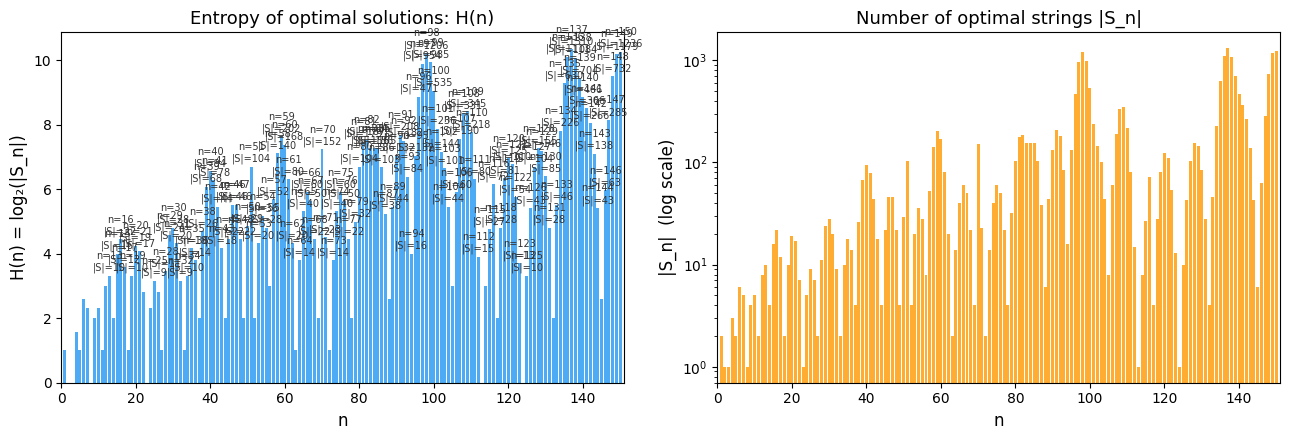

n values with |S_n| > 1:  144 / 150
Max |S_n|: 1310  at n = 137
Max H(n):  10.355  at n = 137

    n     |S_n|      H(n)
  137      1310    10.355
  150      1236    10.271
   98      1206    10.236
  149      1179    10.203
  136      1111    10.118
  138      1084    10.082
   99       985     9.944
   97       954     9.898
  148       732     9.516
  139       704     9.459
  135       630     9.299
  100       535     9.063
   96       471     8.880
  140       466     8.864
  141       366     8.516
  109       345     8.430
  108       331     8.371
  147       285     8.155
  142       266     8.055
  101       236     7.883


In [13]:
import matplotlib.pyplot as plt

ns       = [r["n"] for r in all_results]
num_opts = [r["num_optimal"] for r in all_results]
h_vals   = [math.log2(k) if k > 1 else 0.0 for k in num_opts]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: H(n) vs n
ax = axes[0]
ax.bar(ns, h_vals, color="#2196F3", width=0.8, alpha=0.8)
ax.set_xlabel("n", fontsize=12)
ax.set_ylabel("H(n) = log₂(|S_n|)", fontsize=12)
ax.set_title("Entropy of optimal solutions: H(n)", fontsize=13)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlim(0, max(ns) + 1)

# Annotate notable peaks
for n, h in zip(ns, h_vals):
    if h > 3.0:
        ax.annotate(f"n={n}\n|S|={round(2**h)}", xy=(n, h), xytext=(n, h + 0.15),
                    fontsize=7, ha="center", color="#333")

# Right: |S_n| vs n (log scale)
ax2 = axes[1]
ax2.bar(ns, num_opts, color="#FF9800", width=0.8, alpha=0.8)
ax2.set_xlabel("n", fontsize=12)
ax2.set_yscale("log")
ax2.set_ylabel("|S_n|  (log scale)", fontsize=12)
ax2.set_title("Number of optimal strings |S_n|", fontsize=13)
ax2.set_xlim(0, max(ns) + 1)

plt.tight_layout()
plt.show()

# Summary
nonzero = [(n, k, h) for n, k, h in zip(ns, num_opts, h_vals) if k > 1]
print(f"n values with |S_n| > 1:  {len(nonzero)} / {len(ns)}")
print(f"Max |S_n|: {max(num_opts)}  at n = {ns[num_opts.index(max(num_opts))]}")
print(f"Max H(n):  {max(h_vals):.3f}  at n = {ns[h_vals.index(max(h_vals))]}")
print()
print(f"{'n':>5}  {'|S_n|':>8}  {'H(n)':>8}")
for n, k, h in sorted(nonzero, key=lambda x: -x[1])[:20]:
    print(f"{n:>5}  {k:>8}  {h:>8.3f}")


## Entropy of Optimal Solutions

Let $S_n$ denote the set of all optimal strings of length $n$ (those achieving $a(n)$). Define the combinatorial entropy

$$H(n) = \log_2 |S_n|.$$

$H(n) = 0$ means the optimal string is unique; $H(n) = 1$ means exactly 2 optimal strings; $H(n) = k$ means $2^k$ optimal strings.

**Empirical observations (n ≤ 150):**
- $H(n)$ is almost always 0 or very small — unique or near-unique optima are the norm.
- At several values of $n$, $|S_n|$ jumps above 1, but $H(n)$ remains well below 4.
- Optimal strings share large common prefixes, suggesting the solution space has low entropy relative to the full $2^n$ binary strings.

**Conjectural statement:** $H(n)$ grows sublinearly in $n$, possibly $O(\log n)$. Even proving a polynomial bound $H(n) = O(n^\alpha)$ for some $\alpha < 1$ would be non-trivial.


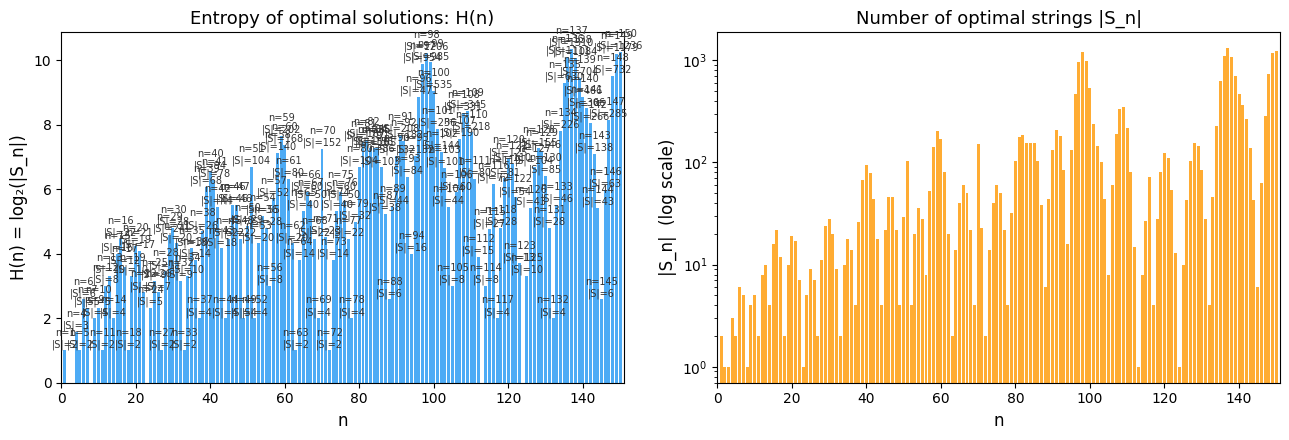

n values with |S_n| > 1:  144 / 150
Max |S_n|: 1310  at n = 137
Max H(n):  10.355  at n = 137

    n     |S_n|      H(n)
  137      1310    10.355
  150      1236    10.271
   98      1206    10.236
  149      1179    10.203
  136      1111    10.118
  138      1084    10.082
   99       985     9.944
   97       954     9.898
  148       732     9.516
  139       704     9.459
  135       630     9.299
  100       535     9.063
   96       471     8.880
  140       466     8.864
  141       366     8.516
  109       345     8.430
  108       331     8.371
  147       285     8.155
  142       266     8.055
  101       236     7.883
  134       226     7.820
  110       218     7.768
   91       208     7.700
   59       202     7.658
  107       190     7.570
   82       187     7.547
   92       182     7.508
   81       179     7.484
   60       168     7.392
   83       156     7.285
   84       156     7.285
   85       155     7.276
  128       155     7.276
   70       152     7

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

ns          = [r["n"] for r in all_results]
num_opts    = [r["num_optimal"] for r in all_results]
h_vals      = [math.log2(k) if k > 1 else 0.0 for k in num_opts]

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: H(n) vs n
ax = axes[0]
ax.bar(ns, h_vals, color="#2196F3", width=0.8, alpha=0.8)
ax.set_xlabel("n", fontsize=12)
ax.set_ylabel("H(n) = log₂(|S_n|)", fontsize=12)
ax.set_title("Entropy of optimal solutions: H(n)", fontsize=13)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlim(0, max(ns) + 1)

# Annotate non-zero peaks
for n, h in zip(ns, h_vals):
    if h > 0.5:
        ax.annotate(f"n={n}\n|S|={2**h:.0f}", xy=(n, h), xytext=(n, h + 0.1),
                    fontsize=7, ha="center", color="#333")

# Right: |S_n| vs n (log scale when > 1)
ax2 = axes[1]
ax2.bar(ns, num_opts, color="#FF9800", width=0.8, alpha=0.8)
ax2.set_xlabel("n", fontsize=12)
ax2.set_ylabel("|S_n|  (# optimal strings)", fontsize=12)
ax2.set_title("Number of optimal strings |S_n|", fontsize=13)
ax2.set_xlim(0, max(ns) + 1)
if max(num_opts) > 10:
    ax2.set_yscale("log")
    ax2.set_ylabel("|S_n|  (log scale)", fontsize=12)

plt.tight_layout()
plt.savefig("../output/charts/entropy_H_n.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
nonzero = [(n, k, h) for n, k, h in zip(ns, num_opts, h_vals) if k > 1]
print(f"n values with |S_n| > 1:  {len(nonzero)} / {len(ns)}")
print(f"Max |S_n|: {max(num_opts)}  at n = {ns[num_opts.index(max(num_opts))]}")
print(f"Max H(n):  {max(h_vals):.3f}  at n = {ns[h_vals.index(max(h_vals))]}")
print()
print(f"{'n':>5}  {'|S_n|':>8}  {'H(n)':>8}")
for n, k, h in sorted(nonzero, key=lambda x: -x[1]):
    print(f"{n:>5}  {k:>8}  {h:>8.3f}")
